# Introduction to Data Science – Homework 7
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, March 20, 2026 11:59pm.

In this homework, you will use classification methods to classify handwritten digits (Part 1) and predict airline customer loyalty (Part 2). We hope these exercises will give you an idea of the broad usage of classification methods.

## Your Data
First Name: Ibrahim
<br>
Last Name:  Ergin
<br>
E-mail: u1564808@utah.edu
<br>
UID:    u1564808
<br>

In [27]:
# imports and setup 
import pandas as pd
import numpy as np

from sklearn import tree, svm, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_digits
from sklearn.preprocessing import scale

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

## Part 1: MNIST handwritten digits

The MNIST handwritten digit dataset is a famous test dataset containing images of handwritten digits, together with labels indicating which digit is in each image. You will see that images are just matrices with scalar values, and that we can apply the classification algorithms we studied on them.

Because both the features and the labels are present in this dataset (and labels for large datasets are generally difficult and expensive to obtain), this dataset is frequently used as a benchmark to compare various classification methods. For example, the [MNIST benchmark comparison page](https://yann.lecun.org/exdb/mnist/index.html) provides a comparison of a variety of classification methods on MNIST. (Note that the tests on that page use higher-resolution images than we will use.)

In this problem, we'll use scikit-learn to compare classification methods on the MNIST dataset. 

There are several versions of the MNIST dataset. We'll use the one that is built-into scikit-learn, described [here](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html). 

1) Classes: 10 (one for each digit)
2) Samples total: 1797
3) Samples per class: $\approx$180
4) Dimensionality: 64 (8 pixels by 8 pixels)
5) Features: integers 0-16 (grayscale value; 0 is white, 16 is black)

Here are some examples of the images. Note that the digits have been size-normalized and centered in a fixed-size ($8\times8$ pixels) image.

<img src="http://scikit-learn.org/stable/_images/sphx_glr_plot_digits_classification_001.png" width="500">

Note that we will scale the data before running them through our algorithms. You can read details about scaling and why it's important [here](http://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling).

In [28]:
digits = load_digits()
#X = digits.data
X = scale(digits.data)
y = digits.target
print(type(X))

n_samples, n_features = X.shape
n_digits = len(np.unique(digits.target))
print("n_digits: %d, n_samples %d, n_features %d" % (n_digits, n_samples, n_features))

<class 'numpy.ndarray'>
n_digits: 10, n_samples 1797, n_features 64


In [29]:
# this is what one digit (a zero) looks like
print("===\nThe digit")
print(digits.target[0])

print("===\nThe raw data")
print(digits.images[0])

print("===\nThe scaled data")
print(X[0])

===
The digit
0
===
The raw data
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
===
The scaled data
[ 0.         -0.33501649 -0.04308102  0.27407152 -0.66447751 -0.84412939
 -0.40972392 -0.12502292 -0.05907756 -0.62400926  0.4829745   0.75962245
 -0.05842586  1.12772113  0.87958306 -0.13043338 -0.04462507  0.11144272
  0.89588044 -0.86066632 -1.14964846  0.51547187  1.90596347 -0.11422184
 -0.03337973  0.48648928  0.46988512 -1.49990136 -1.61406277  0.07639777
  1.54181413 -0.04723238  0.          0.76465553  0.05263019 -1.44763006
 -1.73666443  0.04361588  1.43955804  0.         -0.06134367  0.8105536
  0.63011714 -1.12245711 -1.06623158  0.66096475  0.81845076 -0.08874162
 -0.03543326  0.74211893  1.15065212 -0.86867056  0.11012973  0.53761116
 -0.757435

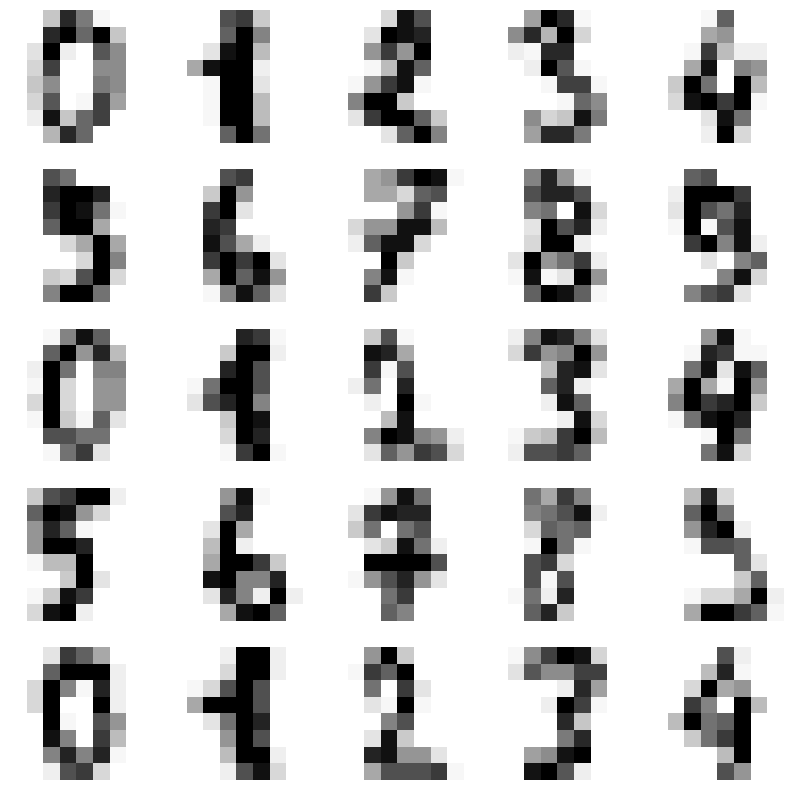

In [30]:
# plot a few of the images
plt.figure(figsize= (10, 10))    
for ii in np.arange(25):
    plt.subplot(5, 5, ii+1)
    plt.imshow(np.reshape(digits.images[ii,:],(8,8)), cmap='Greys',interpolation='nearest')
    plt.axis('off')
plt.show()

You might find [this scikit-learn webpage](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html#sphx-glr-auto-examples-classification-plot-digits-classification-py) to be generally helpful for this exercise. 

### Task 1.1: Classification with Support Vector Machines (SVM)

1. Split the data into a training and test set using `train_test_split(X, y, random_state=1, test_size=0.8)`.
2. Use SVM with an `rbf` kernel and `C=100` to build a classifier from the training set.
3. Evaluate the accuracy and compute the confusion matrix on the test set. Identify the most common mistake. 
*Note: this corresponds to the largest off-diagonal entry of the confusion matrix.*
4. For the most common mistake, print all of the misclassified digits.
5. Use `cross_val_score` to evaluate accuracy for 100 values of C between 1 and 100. What is the best value?
6. Test on raw (non-scaled) data and report the accuracy score for different settings of `gamma`. Use the C value determined previously.

In [31]:
# Part 1
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.8)

indices = np.arange(len(X))
_, test_indices, _, _ = train_test_split(indices, y, random_state=1, test_size=0.8) # this is the same split as above, but we get the indices of the test set

In [32]:
# Part 2
model = svm.SVC(kernel='rbf', C=100)
model.fit(X_train, y_train)    
print(model)

SVC(C=100)


In [33]:
# Part 3
print('Confusion Matrix:')
y_pred = model.predict(X_test)
print(metrics.confusion_matrix(y_true = y_test, y_pred = y_pred))

print('Accuracy = ', metrics.accuracy_score(y_true = y_test, y_pred = y_pred))

Confusion Matrix:
[[130   0   0   0   0   0   0   0   0   0]
 [  0 140   4   0   0   0   0   1   4   0]
 [  0   1 134   0   0   0   0   2   5   0]
 [  0   0   3 136   0   0   0   3   4   1]
 [  0   0   0   0 139   0   0  13   0   0]
 [  0   0   0   0   0 141   1   0   1   4]
 [  0   1   0   0   0   0 144   0   1   0]
 [  0   0   0   0   0   0   0 139   0   1]
 [  0   3   1   1   0   0   0   1 127   0]
 [  0   2   0   2   0   2   1   2   2 141]]
Accuracy =  0.9534075104311543


Rows: true digits (0 through 9)
Columns: predicted digits (0 through 9)

If we look at the highest misclassified digit was 4 and it predicted as 7 by 13 times.

Indices of mistaken predictions: [ 169  225  487  533  721  738 1040 1120 1149 1255 1265 1273 1356]


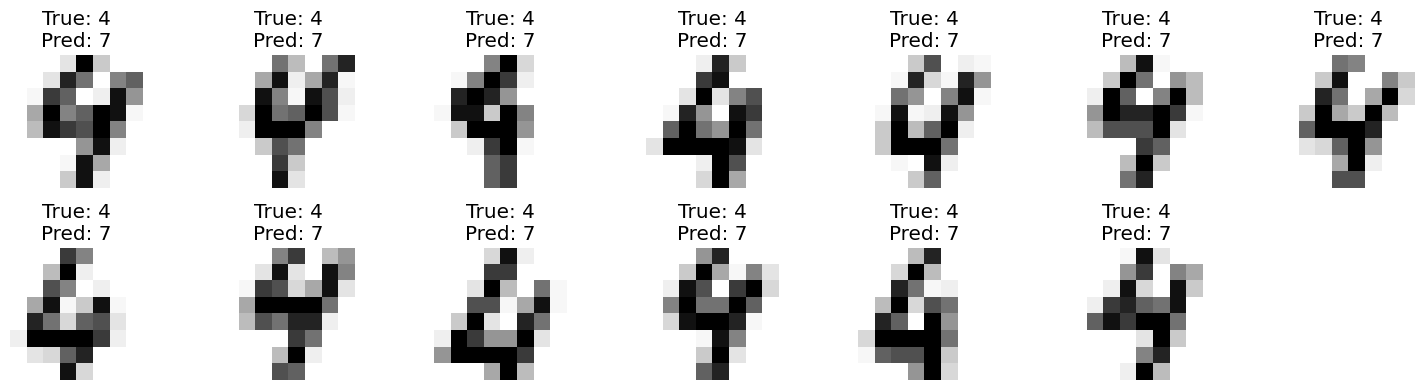

In [34]:
# Part 4
mistake_indices = np.where((y_test == 4) & (y_pred == 7))[0]
print(f"Indices of mistaken predictions: {mistake_indices}")

plt.figure(figsize=(15, 4))
for i, idx in enumerate(mistake_indices):
    plt.subplot(2, 7, i+1)
    img = digits.images[test_indices[idx]]
    plt.imshow(img, cmap='Greys', interpolation='nearest')
    plt.title("True: 4\nPred: 7")
    plt.axis('off')
plt.tight_layout()
plt.show()

Best C: 3.0
Best accuracy: 0.9549179820489012


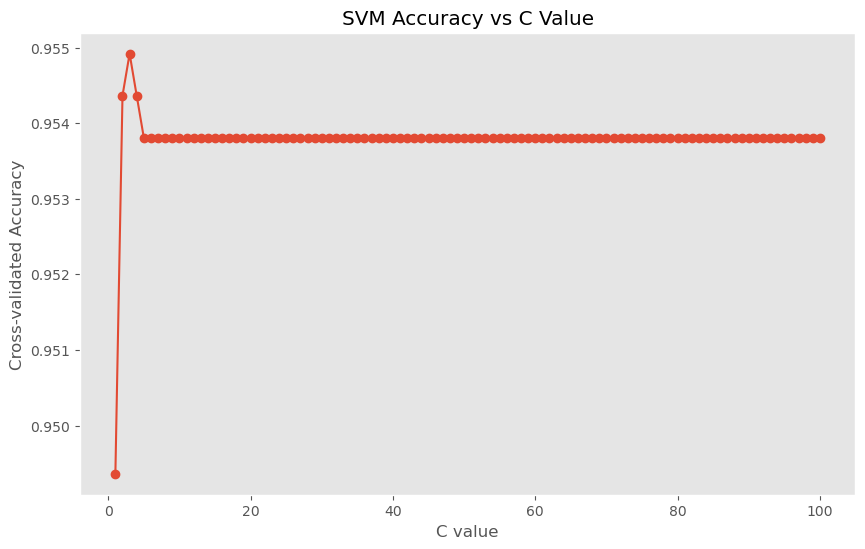

In [35]:
# Part 5

C_values = np.linspace(1, 100, 100)
accuracies = []
for C in C_values:
    model = svm.SVC(kernel='rbf', C=C)
    scores = cross_val_score(model, X, y, cv=5)
    accuracies.append(scores.mean())

best_index = np.argmax(accuracies)
best_C = C_values[best_index]
print("Best C:", best_C)
print("Best accuracy:", accuracies[best_index])

plt.plot(C_values, accuracies, marker='o')
plt.xlabel('C value')
plt.ylabel('Cross-validated Accuracy')
plt.title('SVM Accuracy vs C Value')
plt.grid()
plt.show()

Best C is 3 and its accuracy is 95.49%. It is insteresting that C is actually pretty small, model doesn't need to be very strict to perform well.
In addition, it is very similar to what we found before, beyond certain point, increasing C doesn't help much.

Best gamma: 0.01
Best accuracy: 0.9582637729549249


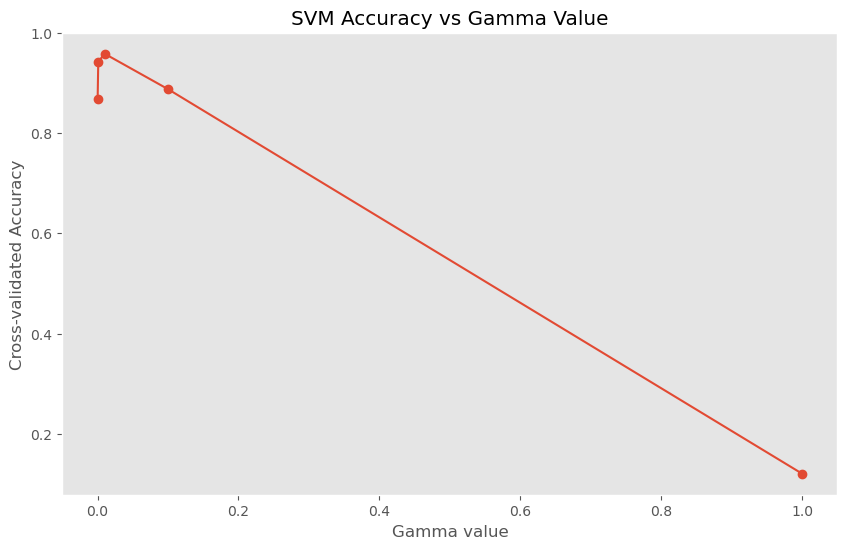

In [36]:
# Part 6

X_raw = digits.data
y = digits.target


gamma_values = [0.0001, 0.001, 0.01, 0.1, 1]
accuracies = []
for gamma in gamma_values:
    model = svm.SVC(kernel='rbf', C=3.0, gamma=gamma)
    scores = cross_val_score(model, X, y, cv=3)
    accuracies.append(scores.mean())

best_index = np.argmax(accuracies)
best_gamma = gamma_values[best_index]
print("Best gamma:", best_gamma)
print("Best accuracy:", accuracies[best_index])

plt.plot(gamma_values, accuracies, marker='o')
plt.xlabel('Gamma value')
plt.ylabel('Cross-validated Accuracy')
plt.title('SVM Accuracy vs Gamma Value')
plt.grid()
plt.show()

Testing on raw (non-scaled) data with C=3.0, the best gamma value was 0.01 with an accuracy of 95.8%, which is slightly higher than the scaled data (95.5%). Accuracy dropped significantly at higher gamma values, showing that gamma selection is important when working with raw unscaled data.

### Task 1.2: Prediction with k-nearest neighbors
Repeat Task 1.1 using k-nearest neighbors (k-NN). 
For part 2, use k=10. 
For part 5, find the best value of k between 1 and 10. 
You do not need to handle non-scaled data for k-NN.

In [37]:
# Part 1

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.8)

indices = np.arange(len(X))
_, test_indices, _, _ = train_test_split(indices, y, random_state=42, test_size=0.8) # this is the same split as above, but we get the indices of the test set

In [38]:
# Part 2
model = KNeighborsClassifier(n_neighbors=10)
model.fit(X_train, y_train)    
print(model)

KNeighborsClassifier(n_neighbors=10)


In [39]:
# Part 3
print('Confusion Matrix:')
y_pred = model.predict(X_test)
print(metrics.confusion_matrix(y_true = y_test, y_pred = y_pred))

print('Accuracy = ', metrics.accuracy_score(y_true = y_test, y_pred = y_pred))

Confusion Matrix:
[[134   0   0   0   0   0   0   0   0   0]
 [  0 121  19   0   0   0   1   0   3   0]
 [  1   2 126   2   0   0   0   0  13   0]
 [  1   0   2 130   0   0   1   4   9   0]
 [  0   2   1   0 133   0   0   3   1   0]
 [  1   1   0   3   1 137   1   0   0   5]
 [  2   1   0   0   0   0 147   0   0   0]
 [  0   0   0   1   0   0   0 147   1   0]
 [  0  14   1   1   0   3   1   0 114   1]
 [  1   6   0   1   0   3   0   8   8 119]]
Accuracy =  0.9095966620305981


Indices of mistaken predictions: [   5   32  235  310  396  426  475  518  542  671  798  856  937 1108
 1197 1296 1341 1384 1422]


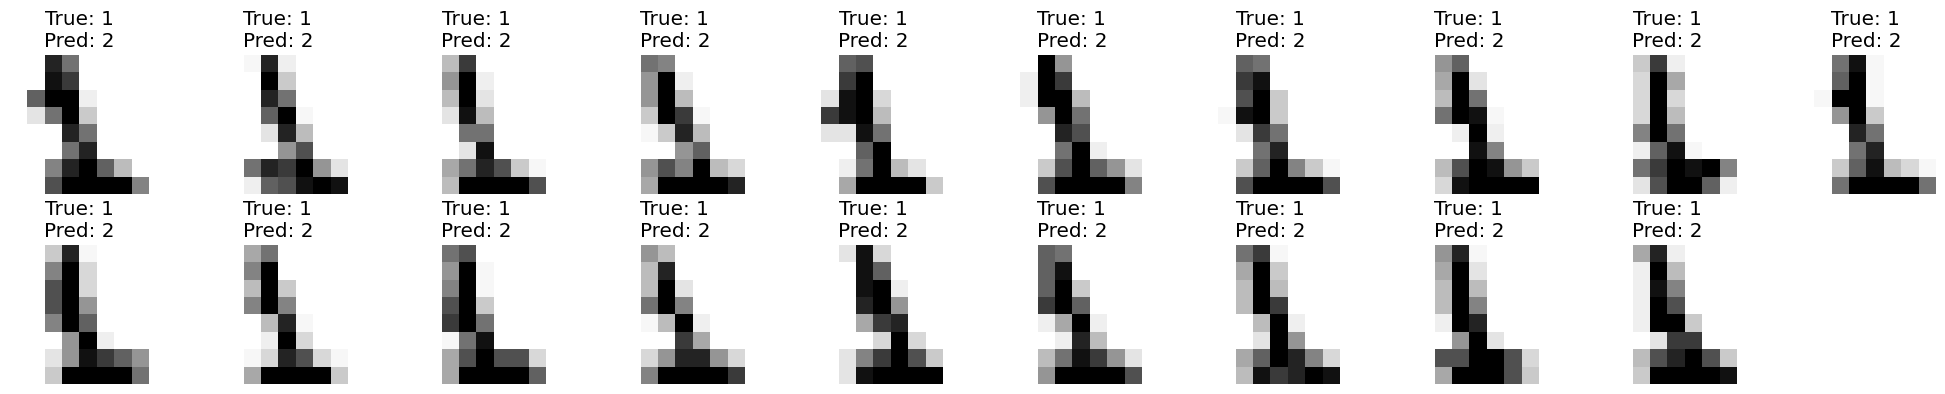

In [40]:
# Part 4
mistake_indices = np.where((y_test == 1) & (y_pred == 2))[0]
print(f"Indices of mistaken predictions: {mistake_indices}")

plt.figure(figsize=(20, 4))
for i, idx in enumerate(mistake_indices):
    plt.subplot(2, 10, i+1)
    img = digits.images[test_indices[idx]]
    plt.imshow(img, cmap='Greys', interpolation='nearest')
    plt.title("True: 1\nPred: 2")
    plt.axis('off')
plt.tight_layout()
plt.show()

Best k: 3
Best accuracy: 0.9449257195914577


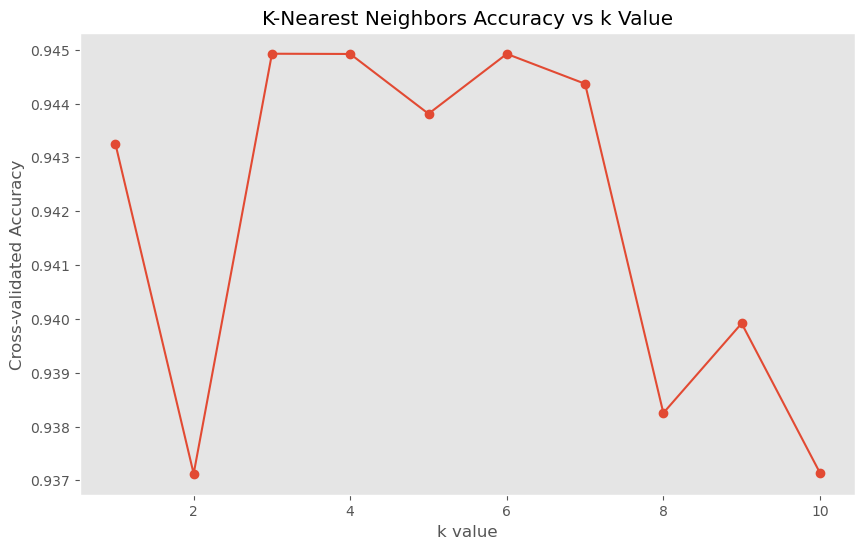

In [41]:
# Part 5

k_values = np.arange(1, 11)
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5)
    accuracies.append(scores.mean())

best_index = np.argmax(accuracies)
best_k = k_values[best_index]
print("Best k:", best_k)
print("Best accuracy:", accuracies[best_index])

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k value')
plt.ylabel('Cross-validated Accuracy')
plt.title('K-Nearest Neighbors Accuracy vs k Value')
plt.grid()
plt.show()

# Part 2: Predicting Airline Customer Loyalty

In this problem, you will use classification tools to predict whether a customer is a "Loyal Customer" or a "disloyal Customer". This information is critical for the airline's retention strategy.

### Task 2.1 Import and Preprocessing
* Use `pandas.read_csv()` to import the dataset `airline_survey.csv`. 
* Convert ordinal and categorical columns ('Gender', 'Type of Travel', 'Class', 'Customer Type') to numerical data.
* Drop all rows with NaN values.

In [42]:
# your solution goes here
df = pd.read_csv("airline_survey.csv")
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,70172,Male,Loyal Customer,13.0,Personal Travel,Eco Plus,460,3,4,3,...,5,5,4,3,4,4,5,5,25,18.0
1,5047,Male,disloyal Customer,25.0,Business travel,Business,235,3,2,3,...,1,1,1,5,3,1,4,1,1,6.0
2,110028,Female,Loyal Customer,26.0,Business travel,Business,1142,2,2,2,...,5,5,4,3,4,4,4,5,0,0.0
3,24026,Female,Loyal Customer,25.0,Business travel,Business,562,2,5,5,...,2,2,2,5,3,1,4,2,11,9.0
4,119299,Male,Loyal Customer,61.0,Business travel,NaN,214,3,3,3,...,5,3,3,4,4,3,3,3,0,0.0


In [43]:
# information about the dataset
print(df.info())
print(50 * "*-")
print(f"Shape of the dataset: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                98696 non-null   float64
 4   Type of Travel                     103904 non-null  object 
 5   Class                              98677 non-null   object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     1039

In [44]:
# check the unique values in the categorical columns
print(df['Gender'].unique())
print(df['Customer Type'].unique())
print(df['Type of Travel'].unique())
print(df['Class'].unique())

['Male' 'Female']
['Loyal Customer' 'disloyal Customer']
['Personal Travel' 'Business travel']
['Eco Plus' 'Business' nan 'Eco']


In [45]:
# convert categorical columns
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})
df['Class'] = df['Class'].map({'Eco': 0, 'Eco Plus': 1, 'Business': 2})

# drop NaN rows
df = df.dropna()

print(df.shape)

(93454, 23)


### Task 2.2 Predictor and Predicted Variable
* Export the predictor variables as a numpy array called *X*. Drop the 'id' and 'Customer Type' columns for this array.
* Export the 'Customer Type' column as a binary numpy array called *y* (e.g., Loyal=1, Disloyal=0).
* Print the *y* array.

In [46]:
# your solution goes here
X = df.drop(columns=['id', 'Customer Type']).to_numpy()
y = df['Customer Type'].to_numpy()
print(y)

[1 0 1 ... 0 0 1]


### Task 2.3 Classification using k-NN
Develop a k-NN classification model to predict loyalty. Use cross-validation to choose the best value of k. Plot the accuracy for various values of k (e.g., 1 to 30).

Best k: 27
Best accuracy: 0.8373424038298619


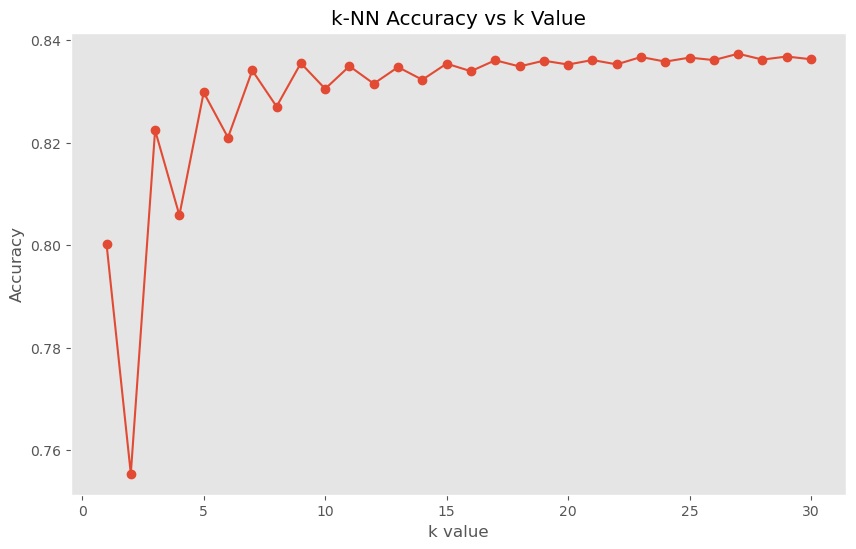

In [47]:
# your solution goes here
ks = np.arange(1, 31)
accuracies = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5)
    accuracies.append(scores.mean())

best_index = np.argmax(accuracies)
best_k = ks[best_index]
print("Best k:", best_k)
print("Best accuracy:", accuracies[best_index])

plt.plot(ks, accuracies, marker='o')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('k-NN Accuracy vs k Value')
plt.grid()
plt.show()

### Task 2.4 Classification using SVM
Develop an SVM classification model for loyalty prediction. Show the results of cross-validation.

*Hint: Use a subset of the data (e.g., 4,000 samples) if processing time is too long*.

In [48]:
# your solution goes here
X_subset = X[:4000]
y_subset = y[:4000]

model = svm.SVC(kernel='rbf') # default C=1.0, gamma='scale'
scores = cross_val_score(model, X_subset, y_subset, cv=5)
print("Cross-validated Accuracy:", scores.mean())



Cross-validated Accuracy: 0.8195


### Task 2.5 Classification using Decision Trees
Develop a decision tree model. Use cross-validation to tune `max_depth` and `min_samples_split`. Show the cross-validation output and optimal parameters.

In [49]:
max_depths = [5, 10, 15, 20]
min_splits = [10, 100, 200, 400, 800]

# your solution goes here
best_accuracy = 0
best_params = {}

for depth in max_depths:
    for min_split in min_splits:
        model = tree.DecisionTreeClassifier(max_depth=depth, min_samples_split=min_split)
        scores = cross_val_score(model, X, y, cv=5)
        accuracy = scores.mean()
        print(f"max_depth={depth}, min_samples_split={min_split}, accuracy={accuracy:.4f}")
        
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params = {'max_depth': depth, 'min_samples_split': min_split}

print("\nBest params:", best_params)
print("Best accuracy:", best_accuracy)

max_depth=5, min_samples_split=10, accuracy=0.8977
max_depth=5, min_samples_split=100, accuracy=0.8977
max_depth=5, min_samples_split=200, accuracy=0.8977
max_depth=5, min_samples_split=400, accuracy=0.8977
max_depth=5, min_samples_split=800, accuracy=0.8972
max_depth=10, min_samples_split=10, accuracy=0.9529
max_depth=10, min_samples_split=100, accuracy=0.9509
max_depth=10, min_samples_split=200, accuracy=0.9494
max_depth=10, min_samples_split=400, accuracy=0.9445
max_depth=10, min_samples_split=800, accuracy=0.9370
max_depth=15, min_samples_split=10, accuracy=0.9686
max_depth=15, min_samples_split=100, accuracy=0.9629
max_depth=15, min_samples_split=200, accuracy=0.9581
max_depth=15, min_samples_split=400, accuracy=0.9486
max_depth=15, min_samples_split=800, accuracy=0.9378
max_depth=20, min_samples_split=10, accuracy=0.9696
max_depth=20, min_samples_split=100, accuracy=0.9632
max_depth=20, min_samples_split=200, accuracy=0.9583
max_depth=20, min_samples_split=400, accuracy=0.9483
ma

### Task 2.6 Describe Your Findings
1. Which method (k-NN, SVM, Decision Tree) was most effective at predicting loyalty?
2. How did parameter changes (like $k$ or tree depth) affect accuracy?
3. Which model provided the most useful insights into why a customer is loyal?

k-NN (best k=27) --> Accuracy: 83.7%
SVM(subset,default) --> Accuracy: 81.9%
Decision Tree(best) --> Accuracy: 96.9%


1. Decision tree is the most effective with 96.9% accuracy. However, SVM was run on a subset with default values (C=1, gamma='scale'), so 
a fair comparison would likely show a smaller gap. Still, the margin is significant.

2. For k-NN, low k values performed poorly and accuracy rose in a zig-zag pattern before plateauing around k=8-30. Best k=27 with 83.7%.
For Decision Tree, max_depth=5 underfit at ~89.7%. Deeper trees performed significantly better, with best accuracy of 96.96% at 
max_depth=20, min_samples_split=10. Larger min_samples_split consistently hurt accuracy.

3. Decision Tree provides the most useful insights. We can trace exactly which features drive loyalty predictions. For example, 
"if Class=Business AND Inflight wifi > 3, then Loyal." k-NN and SVM are essentially black boxes that predict without explaining why.